# Guide3D: annotated-guidewire recovery in acquired images

This companion notebook recomputes the **tables and figures from the committed pilot results**. It does not download Guide3D or rerun image processing. Its only numerical and plotting dependencies are NumPy and Matplotlib.

**PPI enhances line structures generally, but Guide3D labels only the guidewire.** This pilot measures recovery of that annotated structure. Selections elsewhere are unclassified for the broader task: they may include other valid lines or unwanted responses. These labels cannot establish general line-detection precision or false-positive rates.

The images come from a vascular phantom. This is not clinical validation or a reproduction of the private MICCAI 2012 experiment. See the [study report](../docs/benchmarks/guide3d/README.md) for the protocol and image-processing reproduction command. All original measurements and the frozen protocol are retained; the interpretation is corrected for the general line-enhancement objective.

## Goal

Compare polygonal path image (PPI) voting against raw darkness and local dark contrast on held-out **whole acquisitions**. Measure coverage of the annotated guidewire and describe where selected pixels lie relative to it, including variation between acquisitions.

The annotations describe the full tip and shaft of the guidewire, not every visible line. The study therefore cannot decide whether off-guidewire selections are correct or incorrect for general line enhancement. It contains no guidewire-absence controls and makes no three-dimensional reconstruction claim.

## Setup

Open this notebook from a checkout of the repository. To reproduce its saved outputs:

```bash
python -m pip install numpy 'matplotlib>=3.8' jupyterlab
jupyter lab examples/ppi_guide3d_study.ipynb
```

The committed input is `docs/benchmarks/guide3d/results.json`. Raw Guide3D images and annotations remain external to this repository; every figure below uses derived scalar measurements only.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "benchmarks").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "benchmarks" / "plot_guide3d.py").is_file():
    raise RuntimeError("Open this notebook from the repository root or its examples directory.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
from benchmarks.plot_guide3d import (
    load_results,
    macro_summary,
    method_label,
    methods_in,
    plot_acquisitions,
    plot_budget_curves,
    plot_localization,
    plot_precision,
    set_style,
)

set_style()
report = load_results(ROOT / "docs/benchmarks/guide3d/results.json")
rows = report["evaluation"]["rows"]
primary_budget = report["protocol"]["primary_budget"]
native_scale = report["protocol"]["native_pixels_per_working_pixel"]
selected_method = report["selection"]["selected_method"]
methods = methods_in(rows)

## Context and methods

The pilot samples ten evenly spaced paired frames per acquisition and keeps both camera views together. Three acquisitions form the development set; ten whole acquisitions are held out. The sole fluid/straight acquisition appears only in evaluation.

Images are averaged from 1024×1024 to 512×512. The image-derived field of view is eroded by 16 working pixels for evaluation. PPI operates on the image without an annotation-derived crop. The local baseline and local-input PPI receive the same quantized Gaussian-background contrast. A small PPI parameter comparison uses development acquisitions only; the selected configuration is carried to evaluation alongside the unchanged default.

### Metric assumptions

- **Guidewire coverage:** fraction of annotated guidewire arclength inside the ROI within two working pixels (four native pixels) of a selected pixel center.
- **Selected near guidewire:** fraction of selected pixels within that tolerance of the finite annotated guidewire polyline. This is not precision against all visible lines.
- **Off-guidewire rate:** selected pixels outside the guidewire tolerance tube, divided by all ROI pixels outside that tube. Those pixels are not established non-line background; their responses are unclassified for all-line enhancement.
- **Area budgets:** nominal ROI fractions of 0.25%, 0.5%, 1% and 2%. Complete cutoff tie blocks are retained, so actual selected area can exceed the nominal budget.
- **Aggregation:** first average selected views within each acquisition, then give each acquisition equal weight. Ranges show observed acquisition means, not confidence intervals. The acquisitions share the phantom and imaging setup; disjoint groups do not establish statistical independence. Guidewire coverage and the fraction selected near the guidewire have different populations and are not combined into an F1 score.

The stored keys `selected_pixel_precision` and `off_tube_false_positive_rate` are retained for reproducibility. Their names do not make these guidewire-specific measurements general line-detection precision or false-positive rates.

### 1. Check the split and operating points

The loader rejects duplicated case/method/budget rows, unequal method populations and overlapping development/evaluation acquisitions. The table below is derived from the result rows rather than the advertised dataset size.

In [3]:
lines = [
    "| Split | Acquisitions | Paired frames | 2D views | Measurement rows |",
    "|---|---:|---:|---:|---:|",
]
for split in ("development", "evaluation"):
    split_rows = report[split]["rows"]
    acquisitions = {r["acquisition_id"] for r in split_rows}
    pairs = {(r["acquisition_id"], r["frame_number"]) for r in split_rows}
    views = {r["case_id"] for r in split_rows}
    lines.append(
        f"| {split.title()} | {len(acquisitions)} | {len(pairs)} | "
        f"{len(views)} | {len(split_rows):,} |"
    )
display(Markdown("\n".join(lines)))
assert np.isclose(primary_budget, 0.01)
assert np.isclose(native_scale, 2)
assert selected_method in methods
assert all(
    np.isclose(row["selection"]["actual_fraction"], row["metrics"]["selected_fraction"])
    for row in rows
)
print("Split, row-grain and area-fraction checks passed.")

| Split | Acquisitions | Paired frames | 2D views | Measurement rows |
|---|---:|---:|---:|---:|
| Development | 3 | 30 | 60 | 1,440 |
| Evaluation | 10 | 100 | 200 | 4,000 |

Split, row-grain and area-fraction checks passed.


In [4]:
audit = report["audit"]
assert audit["archive_integrity_verified"]
assert not audit["missing_images"]
display(
    Markdown(
        f"The audited archive contains **{audit['image_count']:,} images**. "
        f"The pinned annotation file covers **{audit['annotated_image_count']:,} views "
        f"in {audit['annotated_acquisition_count']} acquisitions**. "
        "These downloaded-source counts differ from the original project's advertised total; "
        "the pilot uses the verified annotated subset."
    )
)

The audited archive contains **8,742 images**. The pinned annotation file covers **8,200 views in 13 acquisitions**. These downloaded-source counts differ from the original project's advertised total; the pilot uses the verified annotated subset.

### 2. Read the development selection

These are development scores, not held-out performance. The predeclared objective is acquisition-average guidewire coverage at the nominal 1% budget; exact ties favor smaller actual selected area, then configuration order.

In [5]:
lines = [
    "| Local-input PPI candidate | Guidewire coverage (%) | Actual selected area (%) | Selected |",
    "|---|---:|---:|:---:|",
]
for candidate in report["selection"]["development_scores"]:
    chosen = "yes" if candidate["method"] == selected_method else ""
    lines.append(
        f"| {method_label(candidate['method'])} | {100 * candidate['coverage']:.2f} | "
        f"{100 * candidate['actual_fraction']:.3f} | {chosen} |"
    )
display(Markdown("\n".join(lines)))

| Local-input PPI candidate | Guidewire coverage (%) | Actual selected area (%) | Selected |
|---|---:|---:|:---:|
| PPI · local default | 69.72 | 1.027 |  |
| PPI · local relaxed | 87.03 | 1.005 | yes |
| PPI · local short | 56.15 | 1.021 |  |

## Results

### 3. Compare held-out measurements at the primary area budget

The primary operating point is **1% nominal ROI area**. Actual area is printed alongside guidewire measurements because ties can change the amount selected. All measurements below are means of acquisition means; the two intensity baselines are separate comparators.

“Selected near guidewire” describes the fraction of selected pixels near the labeled structure, not correctness against all intended lines. “Off-guidewire rate” does not assume pixels outside its tolerance tube are background.

In [6]:
summary = {}
lines = [
    "| Method | Guidewire coverage (%) | Selected near guidewire (%) | "
    "Off-guidewire rate (%) | Actual area (%) |",
    "|---|---:|---:|---:|---:|",
]
for method in methods:
    stats = {
        metric: macro_summary(rows, method, metric, primary_budget)
        for metric in (
            "centerline_coverage",
            "selected_pixel_precision",
            "off_tube_false_positive_rate",
            "actual_fraction",
        )
    }
    summary[method] = stats
    if any(s["valid_acquisitions"] != s["total_acquisitions"] for s in stats.values()):
        raise ValueError(
            f"Incomplete acquisition metrics for {method}; inspect missing values before summarizing."
        )
    values = [100 * stats[key]["mean"] for key in stats]
    marker = " (development choice)" if method == selected_method else ""
    lines.append(
        f"| {method_label(method)}{marker} | {values[0]:.2f} | {values[1]:.2f} | "
        f"{values[2]:.3f} | {values[3]:.3f} |"
    )
display(Markdown("\n".join(lines)))

| Method | Guidewire coverage (%) | Selected near guidewire (%) | Off-guidewire rate (%) | Actual area (%) |
|---|---:|---:|---:|---:|
| Raw darkness | 42.82 | 8.80 | 1.071 | 1.167 |
| Local contrast | 83.27 | 19.96 | 0.815 | 1.012 |
| PPI · raw default | 68.84 | 12.43 | 0.913 | 1.035 |
| PPI · local default | 69.75 | 13.60 | 0.893 | 1.027 |
| PPI · local relaxed (development choice) | 89.14 | 17.29 | 0.837 | 1.005 |

In [7]:
chosen_coverage = summary[selected_method]["centerline_coverage"]["mean"]
local_coverage = summary["local_contrast"]["centerline_coverage"]["mean"]
chosen_near_wire = summary[selected_method]["selected_pixel_precision"]["mean"]
local_near_wire = summary["local_contrast"]["selected_pixel_precision"]["mean"]
display(
    Markdown(
        f"The development-selected PPI configuration covers **{100 * chosen_coverage:.2f}% "
        f"of the annotated guidewire** versus **{100 * local_coverage:.2f}%** for direct "
        f"local contrast ({100 * (chosen_coverage - local_coverage):+.2f} percentage points). "
        f"Of selected pixels, **{100 * chosen_near_wire:.2f}%** and "
        f"**{100 * local_near_wire:.2f}%**, respectively, lie near that guidewire. "
        "The remaining selections are unclassified for general line enhancement, because "
        "other lines are not annotated. These figures do not demonstrate lower all-line "
        "precision for PPI. Actual selected areas and operating-point curves remain "
        "part of the guidewire-coverage comparison."
    )
)

The development-selected PPI configuration covers **89.14% of the annotated guidewire** versus **83.27%** for direct local contrast (+5.87 percentage points). Of selected pixels, **17.29%** and **19.96%**, respectively, lie near that guidewire. The remaining selections are unclassified for general line enhancement, because other lines are not annotated. These figures do not demonstrate lower all-line precision for PPI. Actual selected areas and operating-point curves remain part of the guidewire-coverage comparison.

### 4. Compare selection area and guidewire coverage

The horizontal coordinate is the **actual selected area**, averaged using the same acquisition weights as coverage. Each point comes from a declared area budget. Ringed points identify the primary 1% nominal budget.

The second panel reports selection outside the guidewire annotation; it does not identify those selections as false detections of lines.

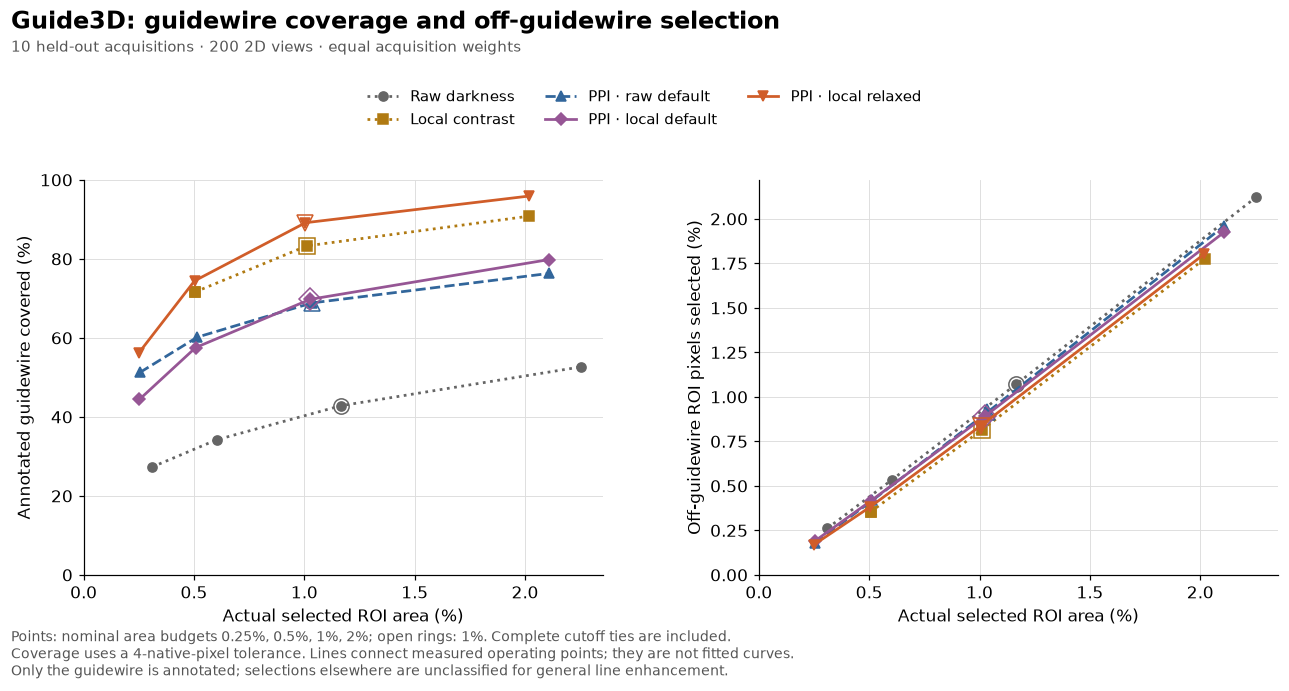

In [8]:
figure = plot_budget_curves(report)
plt.show()

### 5. Check variation between acquisitions

Every cell is a mean across ten paired frames, or twenty 2D views. Comparing methods within each row keeps the acquisition fixed. A high overall guidewire-coverage average does not imply consistent performance across acquisitions or either guidewire type, and says nothing about recovery of unannotated lines.

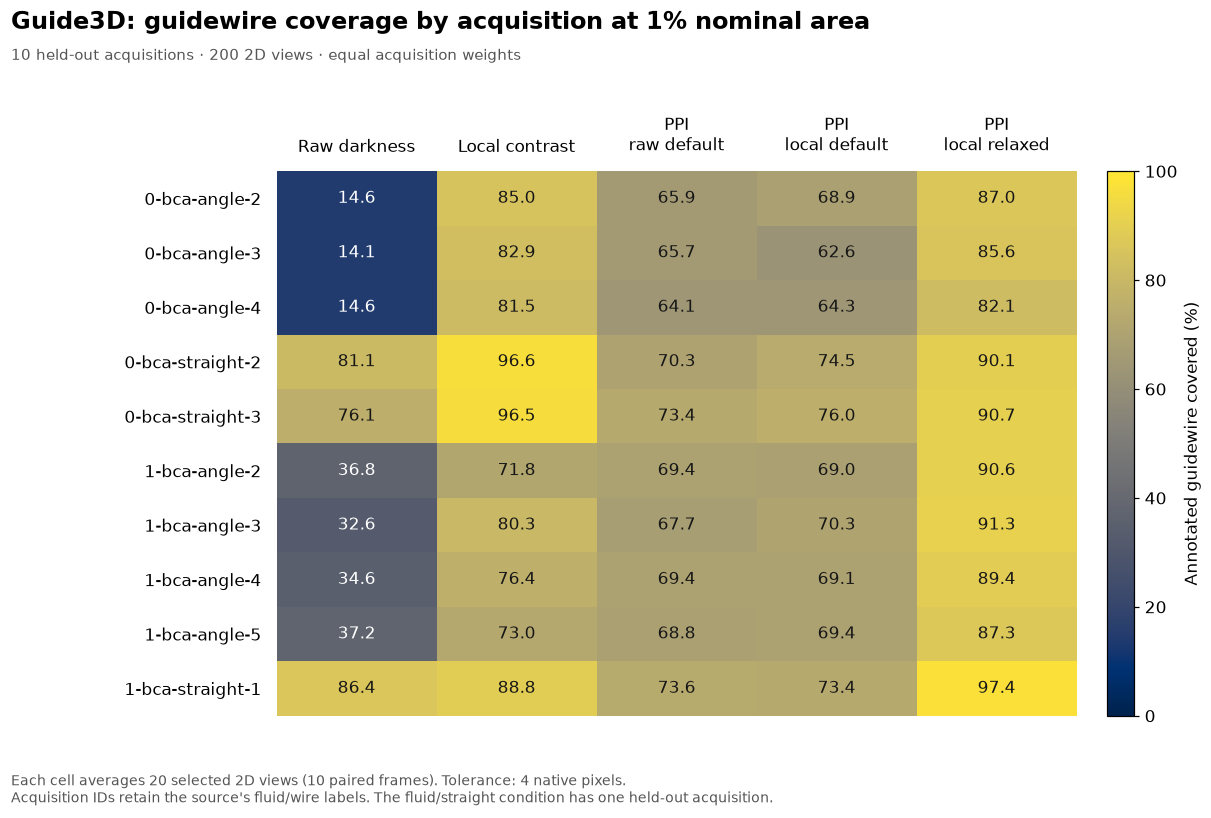

In [9]:
figure = plot_acquisitions(report)
plt.show()

### 6. Describe selection relative to the guidewire

The left panel asks what fraction of selected pixels lies near the annotated guidewire. The right asks what fraction of ROI pixels away from that guidewire was selected. They have different denominators, and neither establishes which off-guidewire responses are valid lines. They are not precision and false-positive rates for the general line-enhancement task.

Horizontal lines span the observed acquisition means; they do not estimate statistical confidence. The helper retains the name `plot_precision` for compatibility, while the figure explicitly identifies its guidewire-only reference.

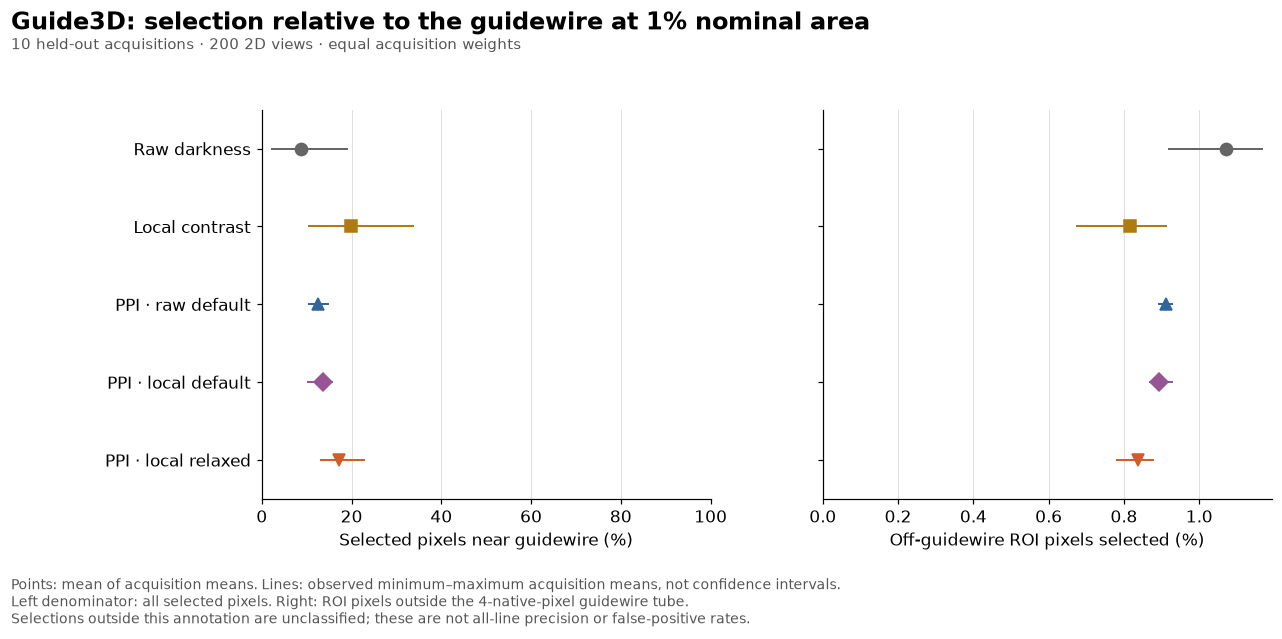

In [10]:
figure = plot_precision(report)
plt.show()

### 7. Measure distances relative to the annotated guidewire

Guidewire-to-selection distance describes gaps in recovery of the guidewire. Selection-to-guidewire distance describes how far selected pixels lie from it. **Distance away from the guidewire does not establish an error or clutter response**: other lines are not annotated.

Distances are expressed in **native pixels**, not millimetres. The chart shows mean distances; per-frame P95 values remain available in the result JSON and are not presented as a pooled P95.

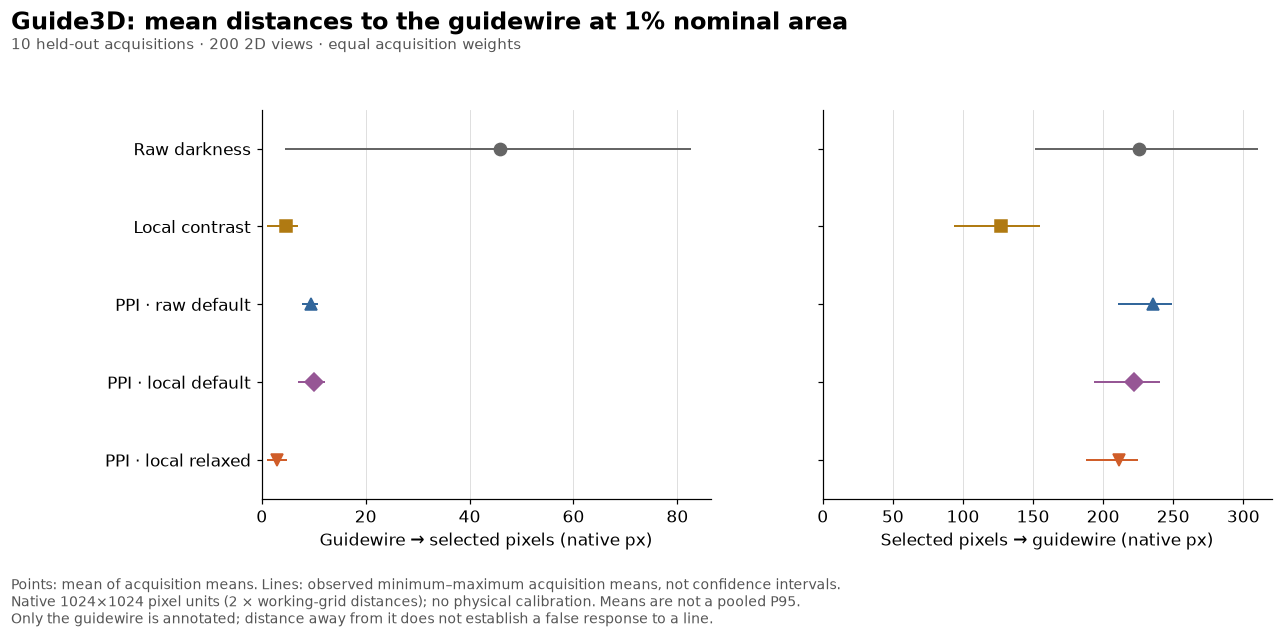

The ROI retains **95.66%** of annotated arclength on average across acquisitions (acquisition means: 95.24–96.31%). Excluded reference samples are not counted as recovered or missed. The retained fraction uses trapezoidal arclength-sample weights, not exact segment clipping.

In [11]:
figure = plot_localization(report)
plt.show()
reference_fraction = macro_summary(rows, "darkness", "reference_length_fraction", primary_budget)
display(
    Markdown(
        f"The ROI retains **{100 * reference_fraction['mean']:.2f}%** of annotated arclength "
        f"on average across acquisitions (acquisition means: "
        f"{100 * reference_fraction['minimum']:.2f}–{100 * reference_fraction['maximum']:.2f}%). "
        "Excluded reference samples are not counted as recovered or missed. The retained fraction "
        "uses trapezoidal arclength-sample weights, not exact segment clipping."
    )
)

## Checks and provenance

Scalar bounds and metric numerator/denominator identities are checked below. These checks verify the published measurements' internal consistency; the study runner separately records input hashes, source hashes and the frozen protocol. The image preprocessing and annotation overlays were inspected during study construction; this scalar-only notebook does not repeat that image audit.

In [12]:
for split in ("development", "evaluation"):
    for row in report[split]["rows"]:
        metric = row["metrics"]
        assert (
            metric["true_positive_pixels"] + metric["false_positive_pixels"]
            == metric["selected_pixels"]
        )
        assert metric["selected_pixels"] <= metric["roi_pixels"]
        for key in (
            "centerline_coverage",
            "selected_pixel_precision",
            "off_tube_false_positive_rate",
            "selected_fraction",
            "reference_length_fraction",
        ):
            value = metric[key]
            assert value is None or 0 <= value <= 1 + 1e-12
        if metric["off_tube_pixels"]:
            assert np.isclose(
                metric["off_tube_false_positive_rate"],
                metric["false_positive_pixels"] / metric["off_tube_pixels"],
            )
print("All scalar range and count checks passed.")
print("Study:", report["protocol"]["study_id"])
print("Protocol frozen:", report["protocol_freeze"]["frozen_at_utc"])
print("Annotation SHA256:", report["protocol"]["sources"]["annotation_sha256"])
print("Image archive SHA256:", report["protocol"]["sources"]["archive_sha256"])

All scalar range and count checks passed.
Study: guide3d-pilot-v1
Protocol frozen: 2026-09-26T11:42:17.809977+00:00
Annotation SHA256: 5b6fa440c15ca66da276fe3619cd9122e5ab8d2ca662768c737e141991abdfc3
Image archive SHA256: 90adb69e69ff8ec128130da33d390cd9b23c51e122d092229c549b1f33d3c236


## Next steps

Evaluate general line enhancement with complete ground truth for every intended line: multiple curves, crossings, and different widths and contrasts, including weak lines beside strong ones. Selection outside the union of all intended line regions can then be assessed as background response. Blank/noise controls need a development-frozen threshold or score-separation analysis; a fixed area quota alone cannot establish absence detection.

Guide3D remains useful as a partial-annotation study of acquired images. Additional frames from the same acquisitions expand exploration, not independent acquisition-level evaluation. The present measurements do not justify suppressing other line structures or changing package defaults.

The original MICCAI 2012 dataset was private. This publicly reproducible phantom study is a new evaluation, not a reconstruction of that experiment.

### Sources and data terms

Guide3D: Tudor Jianu et al., *Guide3D: A Bi-planar X-ray Dataset for 3D Shape Reconstruction*, 2024. [Paper](https://arxiv.org/abs/2410.22224) · [Project](https://airvlab.github.io/guide3d/) · [Dataset](https://huggingface.co/datasets/airvlab/guide3d).

The upstream dataset is identified as [CC BY-NC 4.0](https://creativecommons.org/licenses/by-nc/4.0/). Downloaded images and annotations are not bundled with the package. The figures in this notebook contain derived scalar results, with the dataset and frozen protocol identified above.